# Trajectory with STREAM2 for the patient 2
Trajectory done on all the 5 time points
Apply on the cell type subset : T cells, B cells, macrophages, monocytes, NK 

In [1]:
#!pip uninstall stream2 -y
#!pip install git+https://github.com/pinellolab/STREAM2.git
# Restart the kernel
import stream2 as st2
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
#!pip3 install leidenalg

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  return modu

In [2]:
adata = sc.read("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/seurat_myel.h5ad")

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/_io/h5ad.py:266: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


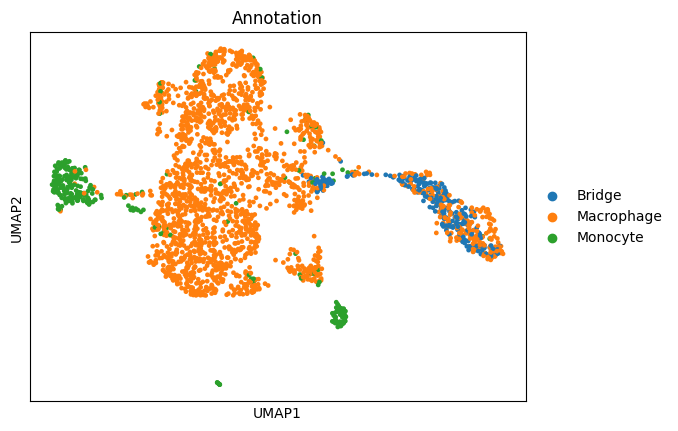

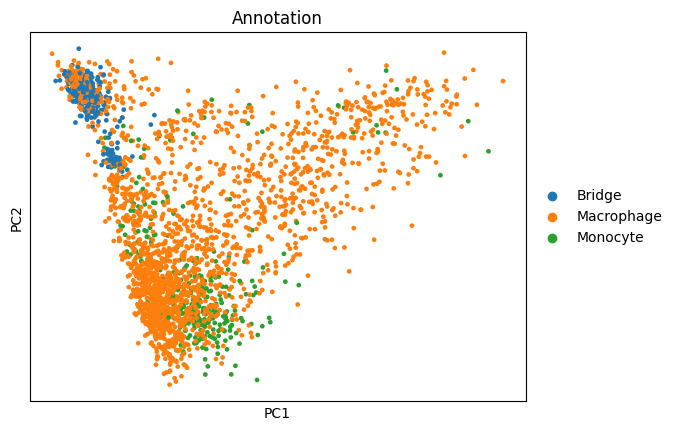

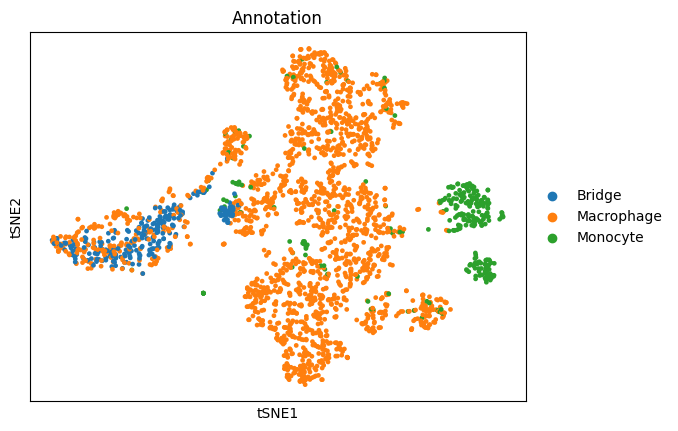

In [6]:
sc.pl.umap(adata,color=['Annotation'])
sc.pl.pca(adata,color=['Annotation'])
sc.pl.tsne(adata,color=['Annotation'])

In [4]:
adata

AnnData object with n_obs × n_vars = 2580 × 18723
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'timepoint', 'doublet_finder', 'percent.mt', 'qc_pass', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA.weight', 'ADT.weight', 'wsnn_res.0.1', 'SingleR', 'predicted.celltype.l1', 'predicted.celltype.l2', 'predicted.celltype.l3', 'manual_annotation', 'final_annot', 'Annotation', 'clone_opt', 'GT_opt', 'p_opt', 'p_cnv', 'compartment_opt', 'RNA_snn_res.0.2'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    uns: 'neighbors', 'Annotation_colors'
    obsm: 'X_adt.umap', 'X_integrated_dr', 'X_pca', 'X_ref.umap', 'X_tsne', 'X_umap', 'X_wnn.umap'
    varm: 'PCs'
    obsp: 'distances'

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:940: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():


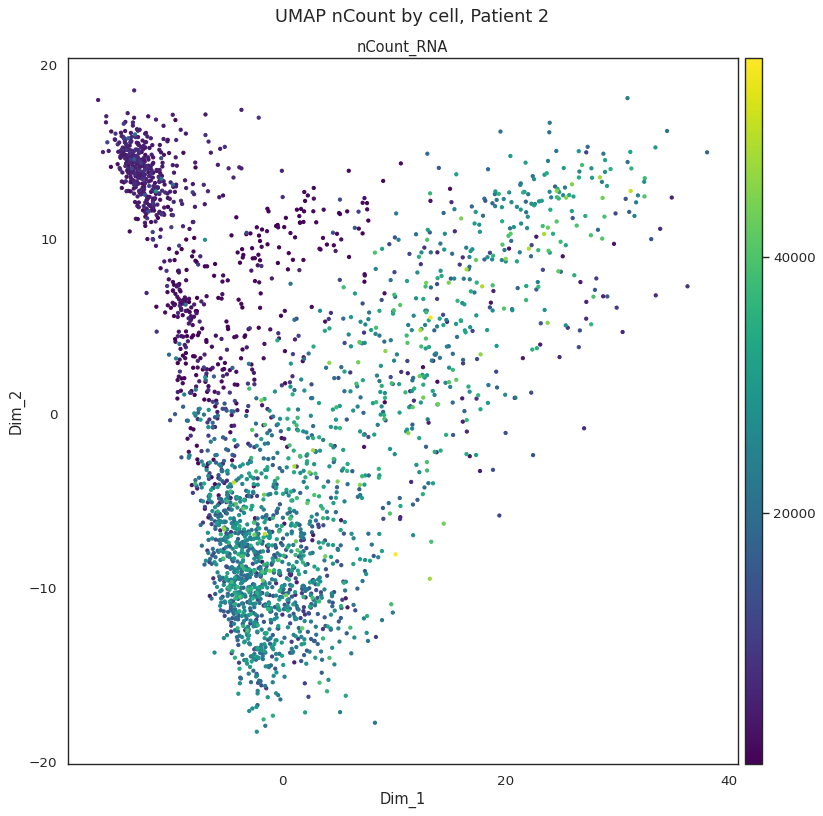

In [7]:
adata.obsm['X_dr'] = adata.obsm['X_pca']
st2.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

st2.pl.dimension_reduction(adata,color=['nCount_RNA'],
                           fig_legend_ncol=2, fig_size=(10,10))
plt.suptitle("UMAP nCount by cell, Patient 2", fontsize=16, y=1.02)
plt.savefig("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots/ncount_p2.png", dpi=300, bbox_inches='tight')

/tmp/ipykernel_48769/3951225322.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


Found 1 components


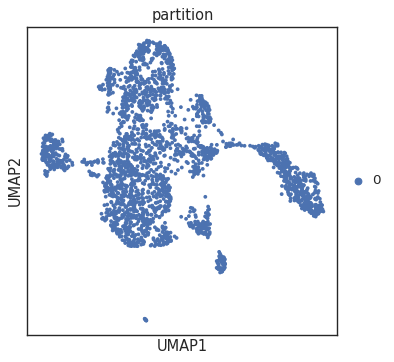

In [8]:
sc.pp.neighbors(adata,use_rep='X_pca')
sc.tl.leiden(adata)
st2.tl.find_disconnected_components(adata,groups='leiden')
sc.pl.umap(adata,color='partition')

<Axes: xlabel='partition'>

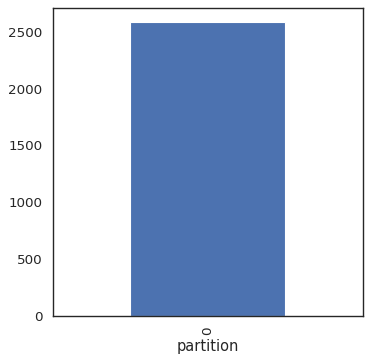

In [9]:
# Many are small clusters which are not adequate for trajectory inference and can be filtered out
# We keep components with more than 500 cells
adata.obs['partition'].value_counts().plot.bar()

Seeding initial graph for each partition...
Learning elastic principal graph for each partition...


/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:1110: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:1110: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():


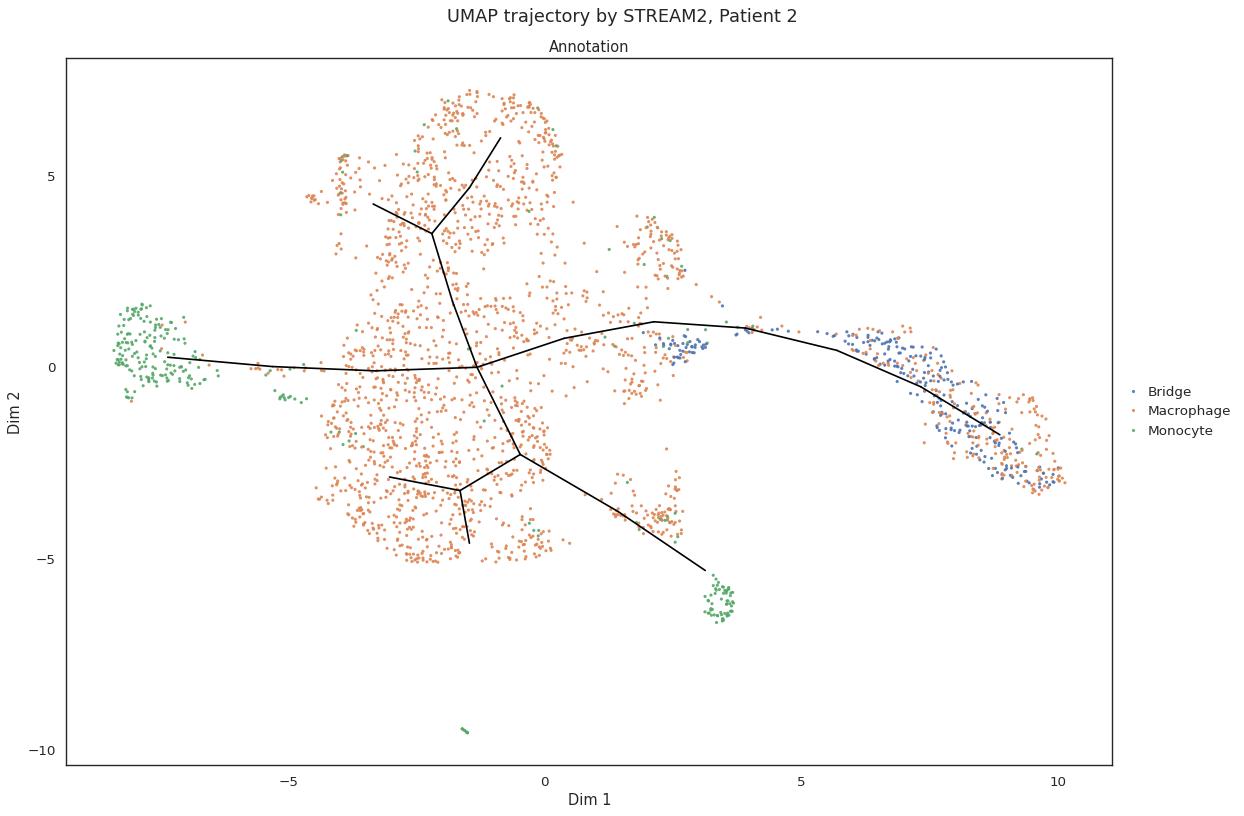

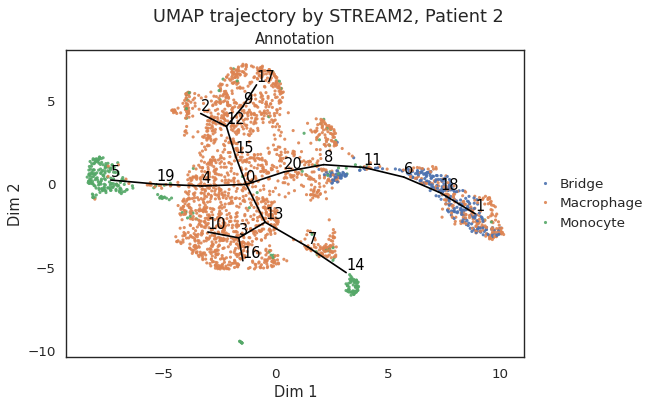

In [47]:
use_partition=['0']
st2.tl.seed_graph(adata, obsm='X_umap', n_clusters=20,use_partition=use_partition)
st2.tl.learn_graph(adata, obsm='X_umap', n_nodes=20,epg_alpha=0.01,epg_mu=0.2,use_partition=use_partition)
st2.pl.graph(adata,key='epg',color=['Annotation'],fig_size=(15,10),save_fig=False)
plt.suptitle("UMAP trajectory by STREAM2, Patient 2", fontsize=16, y=1.02)
plt.savefig("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots/graph_myel_p2.png", dpi=300, bbox_inches='tight')
#adata_sub.uns['epg']['leaves']

st2.tl._elpigraph._store_graph_attributes(adata,adata.obsm['X_umap'],'epg')
st2.pl.graph(adata,key='epg',color=['Annotation'],show_text=True,fig_size=(8,5),save_fig=False)
plt.suptitle("UMAP trajectory by STREAM2, Patient 2", fontsize=16, y=1.02)
plt.savefig("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots/graph_v2_myel_p2.png", dpi=300, bbox_inches='tight')

In [35]:
unique_nodes = sorted(adata.obs['epg_node_id'].dropna().unique())

# Mapping node_id in a label (N1, N2...)
epg_to_label = {node: f"N{int(node)}" for node in unique_nodes}

# Macrostate column
adata.obs["macrostate"] = np.nan
adata.obs["macrostate"] = (
    adata.obs["macrostate"]
    .astype("category")
    .cat.add_categories(sorted(epg_to_label.values()))
)

# Assign the macrostate based on the nearest node
for node, label in epg_to_label.items():
    mask = adata.obs['epg_node_id'] == node
    adata.obs.loc[mask, "macrostate"] = label

print(adata.obs['macrostate'].value_counts())

macrostate
N1     233
N10    225
N8     196
N5     177
N17    171
N4     169
N16    146
N9     136
N18    127
N13    112
N12    104
N15    103
N20    101
N2     101
N0     100
N7      95
N3      88
N14     67
N6      65
N11     33
N19     31
Name: count, dtype: int64


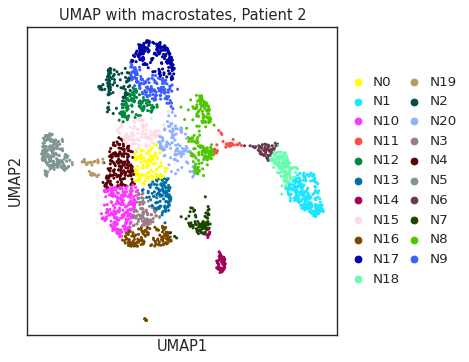

In [50]:
ax = sc.pl.umap(adata,color="macrostate",title="UMAP with macrostates, Patient 2",size=30,show=False)
ax.figure.savefig("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots/umap_macrostages_p2.jpeg", dpi=150, bbox_inches="tight")

In [39]:
sc.pl.umap?

Signature:
sc.pl.umap(
    adata: anndata._core.anndata.AnnData,
    *,
    color: str | collections.abc.Sequence[str] | None = None,
    mask_obs: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.bool]] | str | None = None,
    gene_symbols: str | None = None,
    use_raw: bool | None = None,
    sort_order: bool = True,
    edges: bool = False,
    edges_width: float = 0.1,
    edges_color: str | collections.abc.Sequence[float] | collections.abc.Sequence[str] = 'grey',
    neighbors_key: str | None = None,
    arrows: bool = False,
    arrows_kwds: collections.abc.Mapping[str, typing.Any] | None = None,
    groups: str | collections.abc.Sequence[str] | None = None,
    components: str | collections.abc.Sequence[str] | None = None,
    dimensions: tuple[int, int] | collections.abc.Sequence[tuple[int, int]] | None = None,
    layer: str | None = None,
    projection: Literal['2d', '3d'] = '2d',
    scale_factor: float | None = None,
    color_map: matplotlib.colors.Colormap | st